In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import re
from datetime import datetime
import os

In [21]:


class WuzzufScraper:
    def __init__(self, save_directory="D:"):
        self.base_url = "https://wuzzuf.net/a/IT-Software-Development-Jobs-in-Egypt?start="
        self.headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
            'Accept-Language': 'en-US,en;q=0.9',
        }
        self.jobs_data = []
        self.save_directory = save_directory
        
        if not os.path.exists(self.save_directory):
            os.makedirs(self.save_directory)

    def get_soup(self, url):
        try:
            response = requests.get(url, headers=self.headers)
            response.raise_for_status()
            return BeautifulSoup(response.text, 'html.parser')
        except requests.exceptions.RequestException as e:
            print(f"Request error: {e}")
            return None

    def parse_job_listing(self, job_element):
        try:
            title_element = job_element.find('h2', class_='css-m604qf')
            title = self.clean_data(title_element.text) if title_element else "N/A"
            
            company_element = job_element.find('a', class_='css-17s97q8')
            company = self.clean_data(company_element.text) if company_element else "N/A"
            
            location_element = job_element.find('span', class_='css-5wys0k')
            location = self.clean_data(location_element.text) if location_element else "N/A"
            
            job_type_elements = job_element.select('div.css-1lh32fc span.css-1ve4b75')
            job_type = ", ".join([self.clean_data(e.text) for e in job_type_elements]) if job_type_elements else "N/A"
            
            salary_element = job_element.find('div', class_='css-4xky9y')
            salary = self.clean_data(salary_element.text) if salary_element else "Not disclosed"
            
            # Find skills elements within div.css-y4udm8
            skills_div = job_element.find('div', class_='css-y4udm8')
            skills = "N/A"
            experience = "N/A"
            
            if skills_div:
                skills_elements = skills_div.find_all('a')
                # Extract only the skill names
                skills = ", ".join([self.clean_data(e.text) for e in skills_elements]) if skills_elements else "N/A"
                
                # Look for experience information
                exp_pattern = re.compile(r'\d+\s*-\s*\d+\s*Yrs of Exp')
                exp_spans = skills_div.find_all('span')
                
                for span in exp_spans:
                    if exp_pattern.search(span.text):
                        experience = self.clean_data(span.text)
                        break
            
            return {
                'job_title': title,
                'company': company,
                'location': location,
                'job_type': job_type,
                'salary': salary,
                'skills': skills,
                'experience': experience
            }
            
        except Exception as e:
            print(f"Error parsing job listing: {e}")
            return None

    def scrape_page(self, page_num):
        url = f"{self.base_url}{page_num}"
        print(f"Scraping page: {url}")
        
        soup = self.get_soup(url)
        if not soup:
            return False
        
        job_listings = soup.select('div.css-1gatmva')
        if not job_listings:
            print("No job listings found on this page.")
            return False
        
        for job in job_listings:
            job_data = self.parse_job_listing(job)
            if job_data:
                self.jobs_data.append(job_data)
        
        return True

    def scrape_jobs(self, target_count=2000):
        page_num = 0
        while len(self.jobs_data) < target_count:
            success = self.scrape_page(page_num)
            if not success:
                print("Failed to scrape page or reached the end of listings.")
                break

            print(f"Scraped {len(self.jobs_data)} jobs so far.")
            time.sleep(random.uniform(2, 5))
            page_num += 1

            if page_num > 500:
                print("Reached maximum page limit.")
                break
        
        print(f"Scraping completed. Collected {len(self.jobs_data)} job listings.")

    def save_to_csv(self, filename="wuzzuf_jobs.csv"):
        if not self.jobs_data:
            print("No data to save.")
            return
        
        filepath = os.path.join(self.save_directory, filename)
        df = pd.DataFrame(self.jobs_data)
        df.to_csv(filepath, index=False, encoding='utf-8')
        print(f"Data saved to {filepath}")

    def save_to_excel(self, filename="wuzzuf_jobs.xlsx"):
        if not self.jobs_data:
            print("No data to save.")
            return
        
        filepath = os.path.join(self.save_directory, filename)
        df = pd.DataFrame(self.jobs_data)
        df.to_excel(filepath, index=False)
        print(f"Data saved to {filepath}")

    def clean_data(self, text):
    
        if text:
            return re.sub(r'\s+', ' ', text).strip()
        return ""

    def remove_duplicates(self):
        """Remove duplicate job listings based on title and company."""
        df = pd.DataFrame(self.jobs_data)
        before = len(df)
        df.drop_duplicates(subset=['job_title', 'company'], inplace=True)
        after = len(df)
        print(f"Removed {before - after} duplicates.")
        self.jobs_data = df.to_dict(orient='records')

    

    
        
        


# Run the scraper
if __name__ == "__main__":
    scraper = WuzzufScraper(save_directory="D:")
    scraper.scrape_jobs(target_count=20)
    scraper.remove_duplicates()
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    scraper.save_to_excel(f"wuzzuf_jobs_{timestamp}.xlsx")


Scraping page: https://wuzzuf.net/a/IT-Software-Development-Jobs-in-Egypt?start=0
Scraped 20 jobs so far.
Scraping completed. Collected 20 job listings.
Removed 0 duplicates.
Data saved to D:wuzzuf_jobs_20250501_140740.xlsx


In [2]:
# scraper.remove_duplicates()


In [82]:
import pandas as pd

# Load the saved Excel file
df = pd.read_excel(r"D:wuzzuf_jobs_20250501_113750.xlsx") 



In [83]:
df.head()

,job_title,company,location,job_type,salary,skills,experience
0,Quality Manager,Gazelle Envelope Manufacturers -,"6th of October, Giza, Egypt",Full Time,Not disclosed,"Full Time, On-site, Experienced, · Manufacturi...",· 5 - 7 Yrs of Exp
1,Digital Marketing Manager,IEL Lawfirm -,"Cairo, Egypt",Full Time,Not disclosed,"Full Time, On-site, Manager, · Marketing/PR/Ad...",· 4 - 5 Yrs of Exp
2,e&UAE (Mail and Chat backoffice)B2 English spe...,Etisalat Egypt -,"Maadi, Cairo, Egypt",Full Time,Not disclosed,"Full Time, On-site, Entry Level, · Banking, · ...",· 0 - 5 Yrs of Exp
3,Frontend Engineer,Devency -,"Nozha, Cairo, Egypt",Full Time,Not disclosed,"Full Time, Remote, Experienced, · IT/Software ...",· 2 - 5 Yrs of Exp
4,Accountant,AssureNet -,"New Cairo, Cairo, Egypt",Full Time,Not disclosed,"Full Time, On-site, Entry Level, · Accounting/...",· 0 - 1 Yrs of Exp


In [84]:
def clean_data(text):
    if not text:
        return "N/A"
    text = text.strip()
    start, end = 0, len(text) - 1
    while start < len(text) and not text[start].isalpha():
        start += 1
    while end >= 0 and not text[end].isalpha():
        end -= 1
    return text[start:end+1] if start <= end else "N/A"

def extract_city(location_series):
    cities = []
    for loc in location_series:
        if pd.isna(loc):
            cities.append("N/A")
        elif ',' in loc:
            parts = loc.split(',')
            city = parts[-2].strip() if len(parts) > 1 else "N/A"
            cities.append(city)
        else:
            cities.append("N/A")
    return cities
def extract_country(location_series):
    """Extract country from location string (e.g., 'Nasr City, Cairo, Egypt' → 'Egypt')."""
    countries = []
    updated_locations = []
    for loc in location_series:
        if pd.isna(loc):
            countries.append("N/A")
            updated_locations.append("N/A")
        elif ',' in loc:
            parts = loc.split(',')
            country = parts[-1].strip()
            location_without_country = ', '.join(parts[:-1]).strip()
            countries.append(country)
            updated_locations.append(location_without_country)
        else:
            countries.append("N/A")
            updated_locations.append(loc)
    return updated_locations, countries



df['location'] = df['location'].apply(clean_data)
df['city'] = extract_city(df['location'])
df['location'], df['country'] = extract_country(df['location'])



In [85]:
df.head()

,job_title,company,location,job_type,salary,skills,experience,city,country
0,Quality Manager,Gazelle Envelope Manufacturers -,"th of October, Giza",Full Time,Not disclosed,"Full Time, On-site, Experienced, · Manufacturi...",· 5 - 7 Yrs of Exp,Giza,Egypt
1,Digital Marketing Manager,IEL Lawfirm -,Cairo,Full Time,Not disclosed,"Full Time, On-site, Manager, · Marketing/PR/Ad...",· 4 - 5 Yrs of Exp,Cairo,Egypt
2,e&UAE (Mail and Chat backoffice)B2 English spe...,Etisalat Egypt -,"Maadi, Cairo",Full Time,Not disclosed,"Full Time, On-site, Entry Level, · Banking, · ...",· 0 - 5 Yrs of Exp,Cairo,Egypt
3,Frontend Engineer,Devency -,"Nozha, Cairo",Full Time,Not disclosed,"Full Time, Remote, Experienced, · IT/Software ...",· 2 - 5 Yrs of Exp,Cairo,Egypt
4,Accountant,AssureNet -,"New Cairo, Cairo",Full Time,Not disclosed,"Full Time, On-site, Entry Level, · Accounting/...",· 0 - 1 Yrs of Exp,Cairo,Egypt


In [86]:
df.drop(columns=['salary','location'], inplace=True)


In [87]:
df.head()

,job_title,company,job_type,skills,experience,city,country
0,Quality Manager,Gazelle Envelope Manufacturers -,Full Time,"Full Time, On-site, Experienced, · Manufacturi...",· 5 - 7 Yrs of Exp,Giza,Egypt
1,Digital Marketing Manager,IEL Lawfirm -,Full Time,"Full Time, On-site, Manager, · Marketing/PR/Ad...",· 4 - 5 Yrs of Exp,Cairo,Egypt
2,e&UAE (Mail and Chat backoffice)B2 English spe...,Etisalat Egypt -,Full Time,"Full Time, On-site, Entry Level, · Banking, · ...",· 0 - 5 Yrs of Exp,Cairo,Egypt
3,Frontend Engineer,Devency -,Full Time,"Full Time, Remote, Experienced, · IT/Software ...",· 2 - 5 Yrs of Exp,Cairo,Egypt
4,Accountant,AssureNet -,Full Time,"Full Time, On-site, Entry Level, · Accounting/...",· 0 - 1 Yrs of Exp,Cairo,Egypt


In [88]:
def clean_experience(text):
    if not isinstance(text, str) or not text.strip():
        return "N/A"
    
    # Remove any leading characters that are not letters or numbers
    text = re.sub(r'^[^\w\d]+', '', text).strip()

    return text if text else "N/A"

df['experience'] = df['experience'].apply(clean_experience)


In [89]:
import re

def clean_trailing_symbols(text):
    if not isinstance(text, str) or not text.strip():
        return "N/A"
    
    # Remove any trailing non-letter/number characters
    text = re.sub(r'[\W_]+$', '', text).strip()

    return text if text else "N/A"

df['company'] = df['company'].apply(clean_trailing_symbols)


In [90]:
import re

def clean_job_title(title):
    """
    Extracts only the main job title by removing:
    - Parentheses () and their contents
    - Hyphens - and text after them
    - Slashes / and text after them
    - Any trailing special characters or spaces
    """
    # Remove anything after ( or - or / (including the symbol)
    cleaned_title = re.split(r'[(\-/–]', title)[0].strip()
    
    # Remove trailing special characters (e.g., commas, extra spaces)
    cleaned_title = re.sub(r'[^\w\s]+$', '', cleaned_title).strip()
    
    return cleaned_title

df['job_title'] = df['job_title'].apply(clean_job_title)

In [91]:
df.head()

,job_title,company,job_type,skills,experience,city,country
0,Quality Manager,Gazelle Envelope Manufacturers,Full Time,"Full Time, On-site, Experienced, · Manufacturi...",5 - 7 Yrs of Exp,Giza,Egypt
1,Digital Marketing Manager,IEL Lawfirm,Full Time,"Full Time, On-site, Manager, · Marketing/PR/Ad...",4 - 5 Yrs of Exp,Cairo,Egypt
2,e&UAE,Etisalat Egypt,Full Time,"Full Time, On-site, Entry Level, · Banking, · ...",0 - 5 Yrs of Exp,Cairo,Egypt
3,Frontend Engineer,Devency,Full Time,"Full Time, Remote, Experienced, · IT/Software ...",2 - 5 Yrs of Exp,Cairo,Egypt
4,Accountant,AssureNet,Full Time,"Full Time, On-site, Entry Level, · Accounting/...",0 - 1 Yrs of Exp,Cairo,Egypt


In [92]:
df = df.drop_duplicates(subset=['job_title', 'company'])



SKILLS

In [93]:
df['skills'].head()

0    Full Time, On-site, Experienced, · Manufacturi...
1    Full Time, On-site, Manager, · Marketing/PR/Ad...
2    Full Time, On-site, Entry Level, · Banking, · ...
3    Full Time, Remote, Experienced, · IT/Software ...
4    Full Time, On-site, Entry Level, · Accounting/...
Name: skills, dtype: object

In [94]:
import pandas as pd
import re

def extract_job_details(text):
    """
    Extracts:
    - Work location ("On-site", "Remote", or "N/A")
    - Experience level ("Entry Level", "Experienced", "Manager", or "N/A")
    - Industry (first relevant keyword after location/experience, or "N/A")
    """
    if pd.isna(text):  # Handle NaN values
        return {'work_location': "N/A", 'experience_level': "N/A", 'industry': "N/A"}
    
    # Normalize separators (replace bullets/dots with commas)
    normalized_text = re.sub(r'[·•.,;]', ',', str(text))
    
    # Split into parts and clean
    parts = [part.strip() for part in normalized_text.split(",") if part.strip()]
    
    # Initialize results as "N/A"
    work_location = "N/A"
    experience_level = "N/A"
    industry = "N/A"
    
    # Keywords to check (case-insensitive)
    location_keywords = {"on-site", "remote", "hybrid"}
    experience_keywords = {"entry level", "experienced", "manager"}
    
    for part in parts:
        part_lower = part.lower()
        
        # Skip "Full Time" and empty parts
        if "full time" in part_lower:
            continue
        
        # Check work location
        if work_location == "N/A":  # Only change if it's still "N/A"
            for loc in location_keywords:
                if loc in part_lower:
                    work_location = loc.capitalize()
                    break
        
        # Check experience level
        if experience_level == "N/A":  # Only change if it's still "N/A"
            for exp in experience_keywords:
                if exp in part_lower:
                    experience_level = exp.capitalize()
                    break
        
        # Assign industry (first valid part after location/experience)
        if industry == "N/A":  # Only change if it's still "N/A"
            industry = part
    
    return {
        "work_location": work_location,
        "experience_level": experience_level,
        "industry": industry
    }

# Apply to your DataFrame
df[['work_location', 'experience_level', 'industry']] = df['skills'].apply(
    lambda x: pd.Series(extract_job_details(x))
)


In [95]:
df.head(20)

,job_title,company,job_type,skills,experience,city,country,work_location,experience_level,industry
0,Quality Manager,Gazelle Envelope Manufacturers,Full Time,"Full Time, On-site, Experienced, · Manufacturi...",5 - 7 Yrs of Exp,Giza,Egypt,On-site,Experienced,On-site
1,Digital Marketing Manager,IEL Lawfirm,Full Time,"Full Time, On-site, Manager, · Marketing/PR/Ad...",4 - 5 Yrs of Exp,Cairo,Egypt,On-site,Manager,On-site
2,e&UAE,Etisalat Egypt,Full Time,"Full Time, On-site, Entry Level, · Banking, · ...",0 - 5 Yrs of Exp,Cairo,Egypt,On-site,Entry level,On-site
3,Frontend Engineer,Devency,Full Time,"Full Time, Remote, Experienced, · IT/Software ...",2 - 5 Yrs of Exp,Cairo,Egypt,Remote,Experienced,Remote
4,Accountant,AssureNet,Full Time,"Full Time, On-site, Entry Level, · Accounting/...",0 - 1 Yrs of Exp,Cairo,Egypt,On-site,Entry level,On-site
5,Senior Mechanical Estimator,INNOVATIVE CONSULTING PARTNERS,Full Time,"Full Time, On-site, Experienced, · Engineering...",3 - 8 Yrs of Exp,Cairo,Egypt,On-site,Experienced,On-site
6,Travel Consultant,Airbusinessclass LLC,Full Time,"Full Time, Remote, Entry Level, · Customer Ser...",1 - 5 Yrs of Exp,Cairo,Egypt,Remote,Entry level,Remote
7,Senior Buyer,Global Academic Foundation Hosting University ...,Full Time,"Full Time, On-site, Experienced, · Purchasing/...",4 - 7 Yrs of Exp,Cairo,Egypt,On-site,Experienced,On-site
8,Recruitment Manager,ServiceFirst,Full Time,"Full Time, On-site, Manager, · Human Resources...",3 - 5 Yrs of Exp,Cairo,Egypt,On-site,Manager,On-site
9,Nursery Manager,AME GROUP,Full Time,"Full Time, On-site, Manager, · Administration,...",3 - 15 Yrs of Exp,Cairo,Egypt,On-site,Manager,On-site


In [ ]:
# # Keywords to remove from the skills column
# job_type_keywords = ['Full Time', 'Part Time', 'Freelance', 'Remote', 'On-site', 'Hybrid', 'Internship', 'Shift Based']


# def clean_skills(text):
#     if pd.isna(text):
#         return "N/A"
#     parts = [part.strip() for part in text.split(',')]
#     filtered_parts = [part for part in parts if part not in job_type_keywords]
#     return ', '.join(filtered_parts) if filtered_parts else "N/A"

# df['skills'] = df['skills'].apply(clean_skills)


In [ ]:
# def clean_and_deduplicate_skills(text):
#     if pd.isna(text):
#         return "N/A"
#     skills = [s.strip() for s in text.split(',')]
#     unique_skills = list(dict.fromkeys(skills))  # preserves order & removes duplicates
#     return ', '.join(unique_skills) if unique_skills else "N/A"

# df['skills'] = df['skills'].apply(clean_and_deduplicate_skills)
# df['skills'].head()  

0    Entry Level, Administration, Document, Documen...
1    Experienced, Administration, Customer Service/...
2    Experienced, Engineering - Construction/Civil/...
3    Experienced, Accounting/Finance, Administratio...
4    Entry Level, Customer Service/Support, Logisti...
Name: skills, dtype: object

In [97]:
df.to_excel("final2.xlsx",index=False)

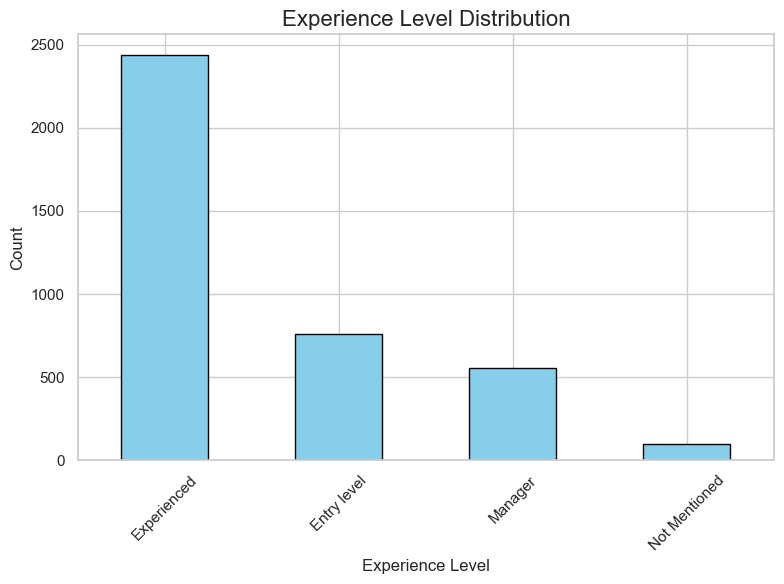

In [117]:
import matplotlib.pyplot as plt

# Replace "N/A" with "Not Mentioned" in the 'experience_level' column
df["experience_level"] = df["experience_level"].replace("N/A", "Not Mentioned")

# Get the value counts for experience_level
experience_counts = df["experience_level"].value_counts()

# Create a bar plot
plt.figure(figsize=(8, 6))
experience_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Customize the chart
plt.title("Experience Level Distribution", fontsize=16)
plt.xlabel("Experience Level", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()


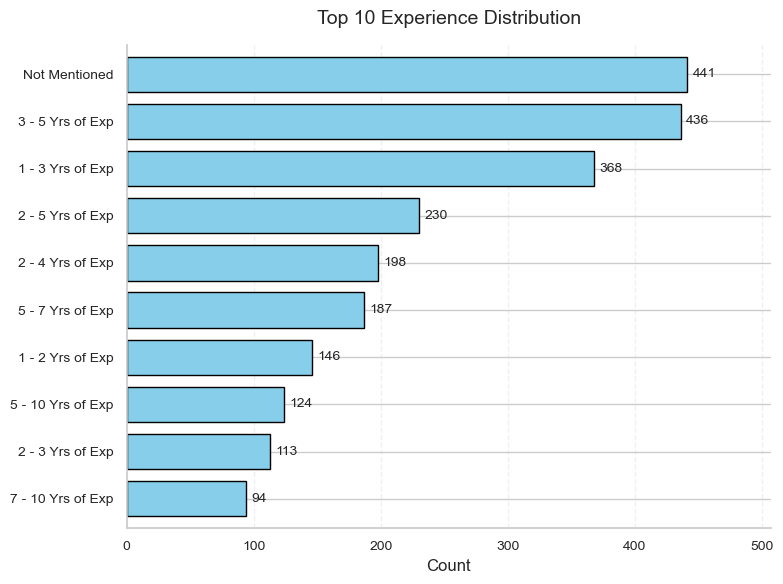

In [123]:
import matplotlib.pyplot as plt

# Data preparation
df["experience"] = df["experience"].replace("N/A", "Not Mentioned")
experience_counts = df["experience"].value_counts().nlargest(10).sort_values()  # Get and sort top 10

# Create figure with your preferred style
plt.figure(figsize=(8, 6))

# Create horizontal bar plot (keeping your color scheme)
ax = experience_counts.plot(
    kind='barh',
    color='skyblue',
    edgecolor='black',
    width=0.75  # Slightly thinner bars
)

# Add count labels with improved positioning
for i, (index, value) in enumerate(experience_counts.items()):
    ax.text(
        value + max(experience_counts)*0.01,  # Small offset from bar end
        i,
        f'{value:,}',  # Format with thousands separator
        va='center',
        ha='left',
        fontsize=10
    )

# Customize the chart (keeping your title style)
plt.title("Top 10 Experience Distribution", fontsize=14, pad=15)
plt.xlabel("Count", fontsize=12)
plt.ylabel("")  # Remove y-label as categories are self-explanatory

# Improve tick labels
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)

# Add subtle grid lines (new improvement)
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Remove top and right spines for cleaner look (new improvement)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust x-axis limit for better spacing
plt.xlim([0, max(experience_counts) * 1.15])

plt.tight_layout()
plt.show()

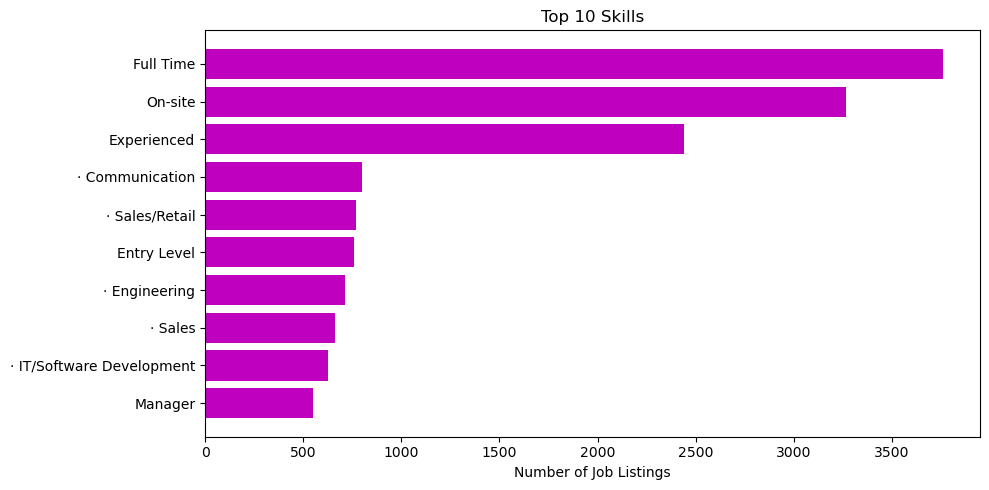

In [98]:
import matplotlib.pyplot as plt
skills_df = pd.DataFrame(top_skills, columns=['Skill', 'Count'])

plt.figure(figsize=(10, 5))
plt.barh(skills_df['Skill'][::-1], skills_df['Count'][::-1], color='m')
plt.title("Top 10 Skills")
plt.xlabel("Number of Job Listings")
plt.tight_layout()
plt.show()


Cities

In [99]:
print("Top cities:\n", df['city'].value_counts().head())

Top cities:
 city
Cairo         2510
Giza           798
Alexandria     242
Sharqia         89
Monufya         34
Name: count, dtype: int64


In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


C:\Users\Maram allah\AppData\Local\Temp\ipykernel_24676\2303442699.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette="Blues_d")


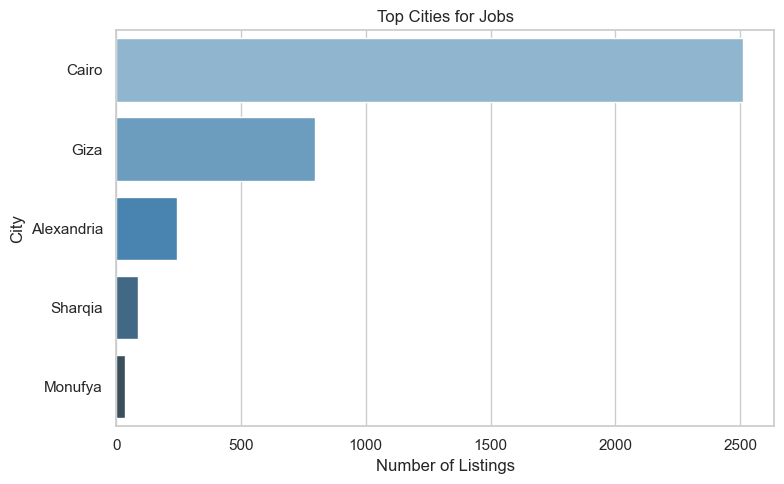

In [101]:
top_cities = df['city'].value_counts().head()

plt.figure(figsize=(8, 5))
sns.barplot(x=top_cities.values, y=top_cities.index, palette="Blues_d")
plt.title("Top Cities for Jobs")
plt.xlabel("Number of Listings")
plt.ylabel("City")
plt.tight_layout()
plt.show()


Companies

In [102]:
print("\nTop companies:\n", df['company'].value_counts().head())


Top companies:
 company
Confidential       364
Etisalat Egypt      16
Intouch CX          16
ECC Group           14
Creative Motion     14
Name: count, dtype: int64


C:\Users\Maram allah\AppData\Local\Temp\ipykernel_24676\3377227945.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, palette="Greens_d")


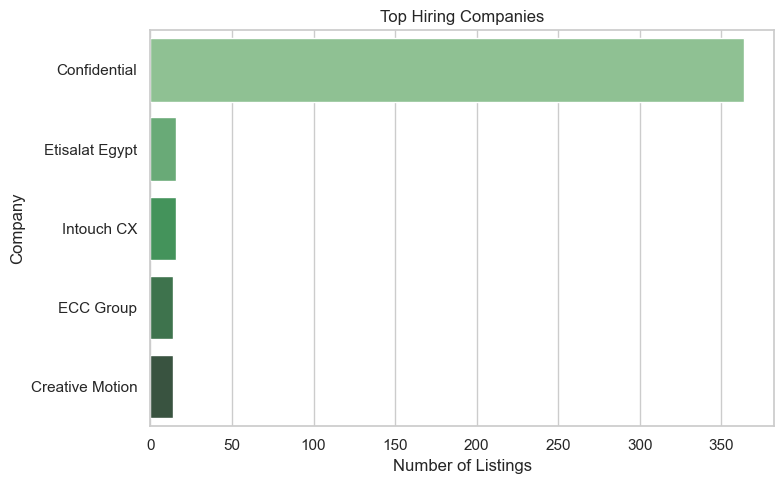

In [103]:
top_companies = df['company'].value_counts().head()

plt.figure(figsize=(8, 5))
sns.barplot(x=top_companies.values, y=top_companies.index, palette="Greens_d")
plt.title("Top Hiring Companies")
plt.xlabel("Number of Listings")
plt.ylabel("Company")
plt.tight_layout()
plt.show()


In [104]:
grouped_df = df.groupby('company')['job_title'].apply(list).reset_index()
grouped_df.columns = ['company', 'job_titles']
grouped_df

,company,job_titles
0,(Delta Textile Egypt,[Engineering manager]
1,(MSA) October University,"[Lecturer in Computer Science, Lecturer in Com..."
2,34ML,"[Cloud Infrastructure Engineer, Vue.Js Fronten..."
3,3Brothers,"[Sales Engineer, Junior Lighting Designer, Ele..."
4,3Concepts For Design & Decoration,[Senior BIM Coordinator]
...,...,...
1556,شركة ادمكو,"[Graphic Designer & Video editor, Content writer]"
1557,شركة الجراج,[Technical Support Engineer]
1558,شركة انتراكتيف العربية السعودية المحدودة,[Sharepoint CMS Developer]
1559,مكاني,[Co]


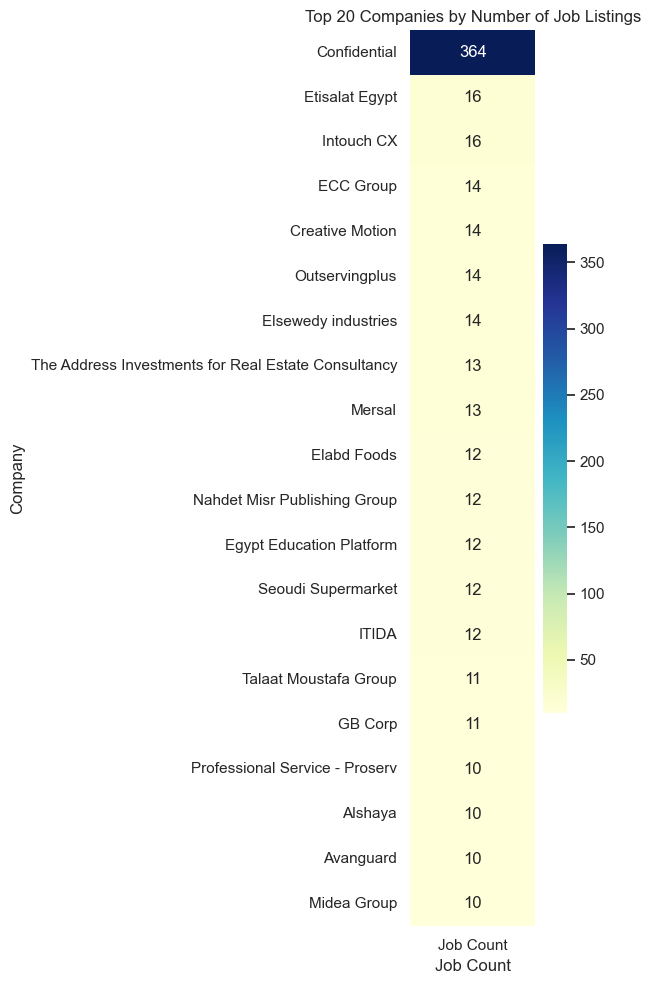

In [105]:

#Count number of job titles per company
job_counts = df['company'].value_counts().head(20).to_frame(name='Job Count')
plt.figure(figsize=(6, 10)) 
sns.heatmap(job_counts, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title("Top 20 Companies by Number of Job Listings")
plt.xlabel("Job Count")
plt.ylabel("Company")
plt.tight_layout()
plt.show()


Job type

In [106]:
print("\nTop job types:\n", df['job_type'].value_counts().head())



Top job types:
 job_type
Full Time               3699
Internship                37
Part Time                 23
Full Time, Part Time      23
Freelance / Project       20
Name: count, dtype: int64


C:\Users\Maram allah\AppData\Local\Temp\ipykernel_24676\800299572.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_job_types.values, y=top_job_types.index, palette="Purples_d")


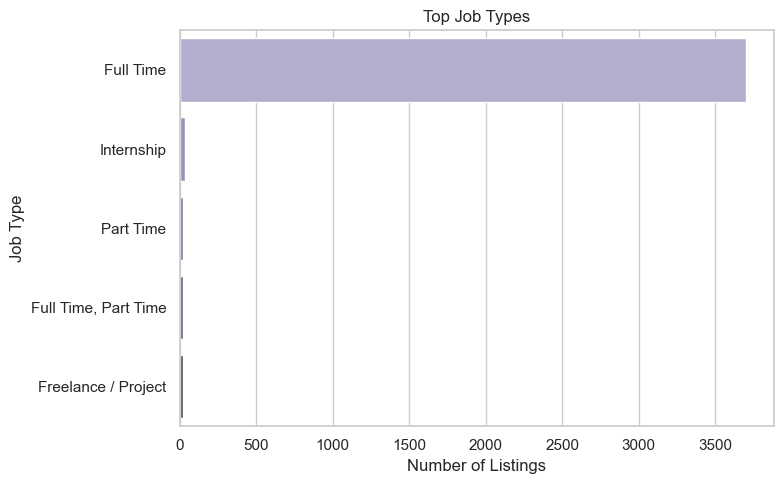

In [107]:
top_job_types = df['job_type'].value_counts().head()

plt.figure(figsize=(8, 5))
sns.barplot(x=top_job_types.values, y=top_job_types.index, palette="Purples_d")
plt.title("Top Job Types")
plt.xlabel("Number of Listings")
plt.ylabel("Job Type")
plt.tight_layout()
plt.show()


In [108]:
# Split the strings into lists
df['job_type_list'] = df['job_type'].str.split(',\s*')

# Use MultiLabelBinarizer to create the boolean columns
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
job_dummies = pd.DataFrame(mlb.fit_transform(df['job_type_list']), columns=mlb.classes_, index=df.index)

# Join the new columns with the original DataFrame
df = df.join(job_dummies).drop(columns=['job_type_list'])


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Maram allah\AppData\Local\Temp\ipykernel_24676\1101188693.py:2: SyntaxWarning: invalid escape sequence '\s'
  df['job_type_list'] = df['job_type'].str.split(',\s*')


In [110]:
df = df.drop(columns='job_type')
df

,job_title,company,skills,experience,city,country,work_location,experience_level,industry,Freelance / Project,Full Time,Internship,Part Time,Shift Based
0,Quality Manager,Gazelle Envelope Manufacturers,"Full Time, On-site, Experienced, · Manufacturi...",5 - 7 Yrs of Exp,Giza,Egypt,On-site,Experienced,On-site,0,1,0,0,0
1,Digital Marketing Manager,IEL Lawfirm,"Full Time, On-site, Manager, · Marketing/PR/Ad...",4 - 5 Yrs of Exp,Cairo,Egypt,On-site,Manager,On-site,0,1,0,0,0
2,e&UAE,Etisalat Egypt,"Full Time, On-site, Entry Level, · Banking, · ...",0 - 5 Yrs of Exp,Cairo,Egypt,On-site,Entry level,On-site,0,1,0,0,0
3,Frontend Engineer,Devency,"Full Time, Remote, Experienced, · IT/Software ...",2 - 5 Yrs of Exp,Cairo,Egypt,Remote,Experienced,Remote,0,1,0,0,0
4,Accountant,AssureNet,"Full Time, On-site, Entry Level, · Accounting/...",0 - 1 Yrs of Exp,Cairo,Egypt,On-site,Entry level,On-site,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3922,Sales Engineer,egy trade,"Full Time, On-site, Experienced, · Sales/Retai...",2 - 5 Yrs of Exp,Cairo,Egypt,On-site,Experienced,On-site,0,1,0,0,0
3923,Mechanical Maintenance Engineer,Outservingplus,"Full Time, On-site, Experienced, · Engineering...",3 - 5 Yrs of Exp,Cairo,Egypt,On-site,Experienced,On-site,0,1,0,0,0
3924,HR Specialist,Softec Technologies,"Full Time, On-site, Experienced, · Administrat...",2 - 2 Yrs of Exp,Cairo,Egypt,On-site,Experienced,On-site,0,1,0,0,0
3925,Architectural Technical Office Engineer,MAX360,"Full Time, On-site, Experienced, · Engineering...",1 - 3 Yrs of Exp,Cairo,Egypt,On-site,Experienced,On-site,0,1,0,0,0


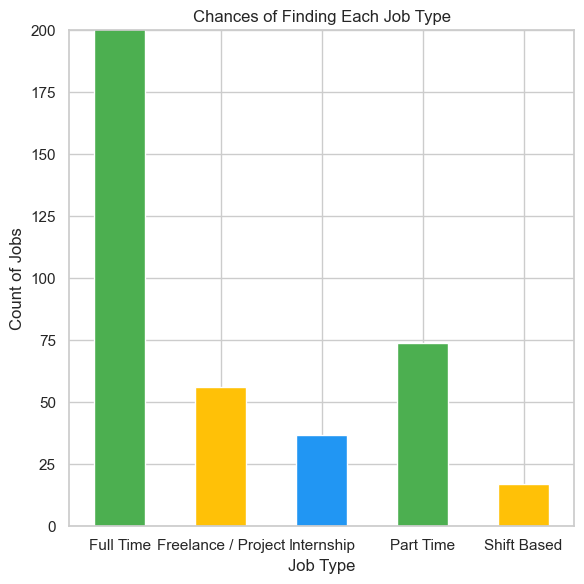

Full Time              3761
Freelance / Project      56
Internship               37
Part Time                74
Shift Based              17
dtype: int64

In [109]:
job_type_counts = df[['Full Time', 'Freelance / Project', 'Internship' ,'Part Time' , 'Shift Based' ]].sum()


job_type_counts.plot(kind='bar', figsize=(6, 6), color=['#4CAF50', '#FFC107', '#2196F3'])
plt.title("Chances of Finding Each Job Type")
plt.xlabel("Job Type")
plt.ylabel("Count of Jobs")
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability

# Manually set the y-axis limits
plt.ylim(0, 200)  # Change 10 to the value you want as the upper limit

plt.tight_layout()
plt.show()

job_type_counts

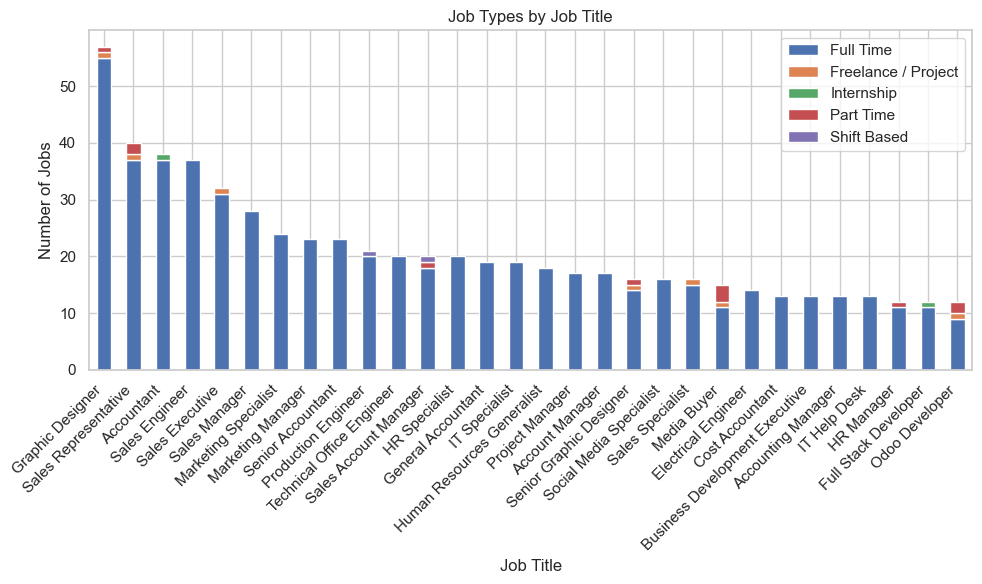

In [111]:
# Group by job_title and sum the boolean columns
grouped = df.groupby('job_title')[['Full Time', 'Freelance / Project', 'Internship' ,'Part Time' , 'Shift Based' ]].sum()

# Optional: keep only top 30 job titles (for readability)
top_jobs = grouped.sum(axis=1).sort_values(ascending=False).head(30).index
grouped = grouped.loc[top_jobs]

# Plot the stacked bar chart
grouped.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Job Types by Job Title")
plt.ylabel("Number of Jobs")
plt.xlabel("Job Title")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Job title

In [112]:
print("\nTop job title:\n", df['job_title'].value_counts().head())


Top job title:
 job_title
Graphic Designer        55
Sales Representative    39
Accountant              38
Sales Engineer          37
Sales Executive         32
Name: count, dtype: int64


In [114]:
!pip install wordcloud

   ---------------------------------------- 0.0/301.2 kB ? eta -:--:--
   - -------------------------------------- 10.2/301.2 kB ? eta -:--:--
   --- ----------------------------------- 30.7/301.2 kB 330.3 kB/s eta 0:00:01
   --------- ----------------------------- 71.7/301.2 kB 563.7 kB/s eta 0:00:01
   --------- ----------------------------- 71.7/301.2 kB 563.7 kB/s eta 0:00:01
   --------- ----------------------------- 71.7/301.2 kB 563.7 kB/s eta 0:00:01
   --------- ----------------------------- 71.7/301.2 kB 563.7 kB/s eta 0:00:01
   ------------------------- ------------ 204.8/301.2 kB 734.2 kB/s eta 0:00:01
   ---------------------------- --------- 225.3/301.2 kB 655.6 kB/s eta 0:00:01
   ---------------------------- --------- 225.3/301.2 kB 655.6 kB/s eta 0:00:01
   ---------------------------- --------- 225.3/301.2 kB 655.6 kB/s eta 0:00:01
   ---------------------------- --------- 225.3/301.2 kB 655.6 kB/s eta 0:00:01
   ---------------------------- --------- 225.3/301.2 kB 

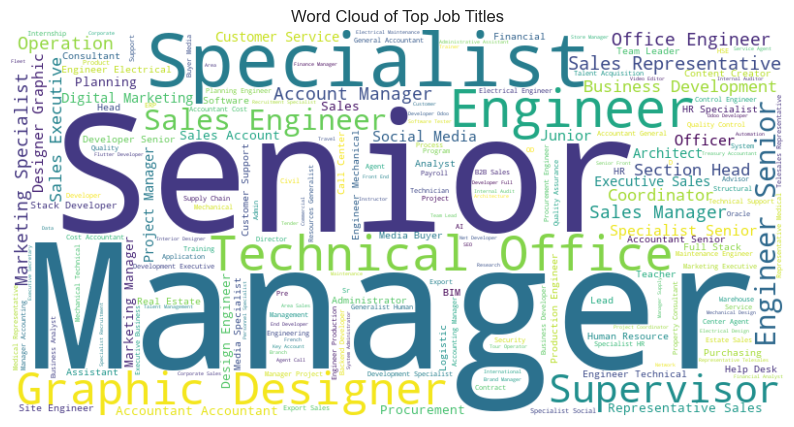

In [115]:
from wordcloud import WordCloud

top_job_titles = df['job_title'].value_counts()

all_job_titles = ' '.join([title for title, count in top_job_titles.items() for _ in range(count)])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_job_titles)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Top Job Titles')
plt.show()


C:\Users\Nourhan\AppData\Local\Temp\ipykernel_6800\3574039661.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_job_title.values, y=top_job_title.index, palette="Reds_d")


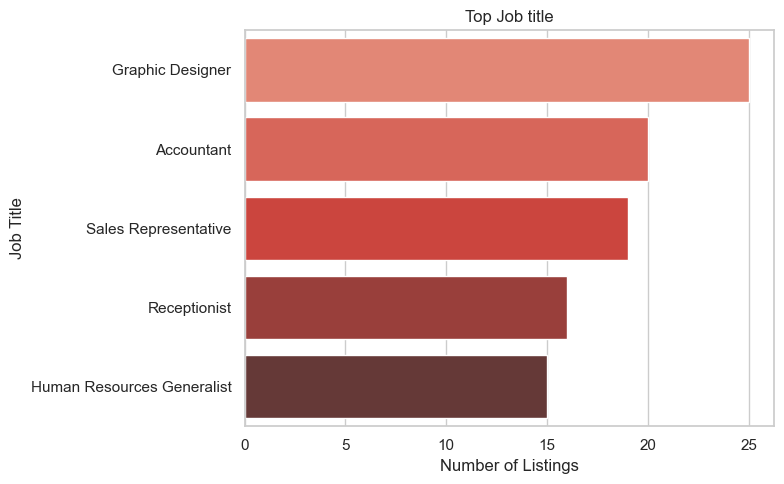

In [25]:
top_job_title = df['job_title'].value_counts().head()

plt.figure(figsize=(8, 5))
sns.barplot(x=top_job_title.values, y=top_job_title.index, palette="Reds_d")
plt.title("Top Job title")
plt.xlabel("Number of Listings")
plt.ylabel("Job Title")
plt.tight_layout()
plt.show()


In [27]:
grouped_df.to_excel("D:\ds tools\web\company_job_titles.xlsx", index=False)


In [28]:
df.to_excel("D:\ds tools\web\wuzzuf.xlsx", index=False)


In [ ]:
# cairo_jobs = df[df['city'].str.lower() == 'cairo']
# print(cairo_jobs.head())

Country

In [ ]:
import plotly.express as px


country_job_counts = df.groupby('country')['job_title'].count().reset_index()

fig = px.choropleth(country_job_counts,
                    locations="country",  # Column containing country names
                    locationmode="country names",  # Match with country names in the map
                    color="job_title",  # Column to base color on (number of job titles)
                    hover_name="country",  
                    color_continuous_scale=px.colors.sequential.Plasma, 
                    labels={"job_title": "Number of Job Titles"},
                    title="Job Title Distribution by Country") 

# Step 3: Show the map
fig.update_geos(showcoastlines=True, coastlinecolor="Black", projection_type="mercator")
fig.update_layout(title_text="Job Titles Across Countries", geo=dict(showframe=False, showcoastlines=True))
fig.show()



# Save data to mongodb data base

# Install important libs

In [ ]:
!pip install pymongo

In [1]:
from pymongo import MongoClient
import pandas as pd

# Load Excel directly into DataFrame
df = pd.read_excel(r"D:\Downloads\meh\output(1).xlsx")

# Connect to MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client["wuzzufDB"]
collection = db["AllJobs"]

# Convert DataFrame to list of dictionaries
records = df.to_dict(orient="records")

# Insert into MongoDB
collection.insert_many(records)

print("Excel data successfully inserted into MongoDB!")


Excel data successfully inserted into MongoDB!
